In [14]:
from neuromodes.io import fetch_surf, fetch_map
from neuromodes.mesh import unmask_data
from neuromodes import EigenSolver
from nsbutils.plotting_pyvista import plot_surf
import numpy as np

In [2]:
geometry, mask = fetch_surf()

In [3]:
solver = EigenSolver(geometry, mask=mask).solve(500)

### eigen

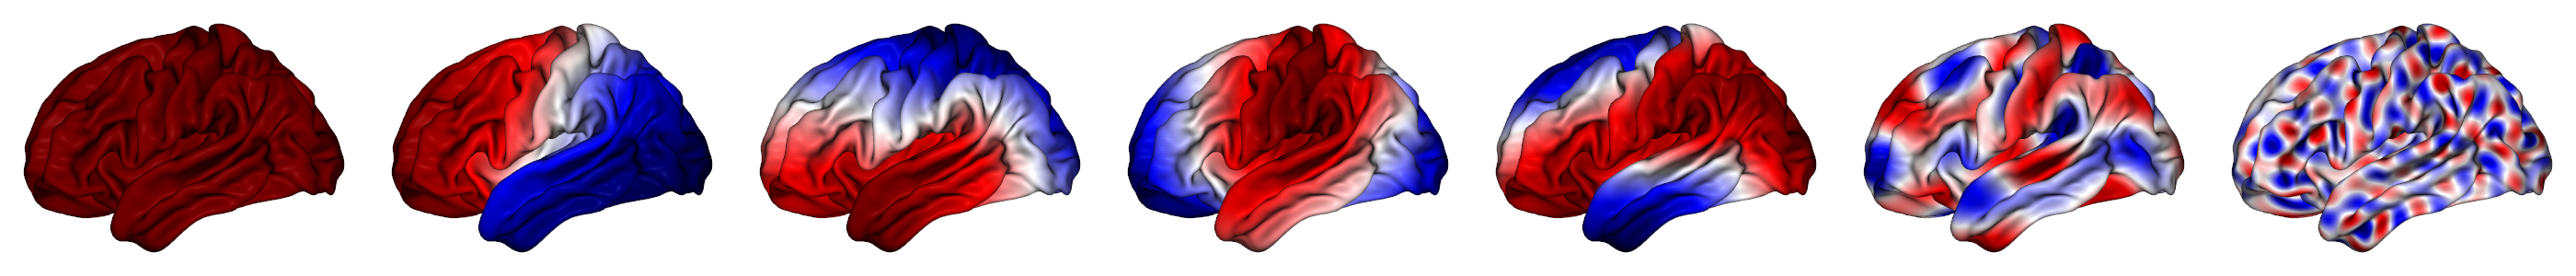

In [12]:
fig = plot_surf({'lh': geometry}, data={'lh': unmask_data(solver.emodes[:, [0, 1, 2, 3, 4, 49, 499]], mask)}, cmap='seismic_r', zoom=1.5)
fig.show(jupyter_backend='static')

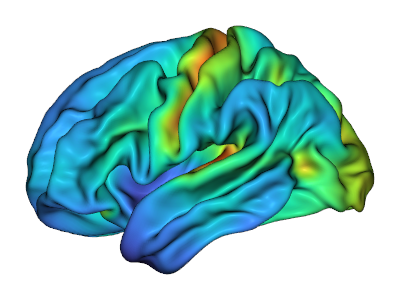

In [15]:
myelinmap = fetch_map('myelinmap')
myelinmap[~mask] = np.nan
fig = plot_surf({'lh': geometry}, data={'lh': myelinmap}, cmap='turbo', zoom=1.5)
fig.show(jupyter_backend='static')

### basis

In [ ]:
fcgradient1 = fetch_map('fcgradient1')[mask]
recon = solver.reconstruct(fcgradient1, mode_counts=[10, 20, 100])

In [18]:
data_unmasked = unmask_data(np.concatenate([fcgradient1[:, None], recon], axis=1), mask)

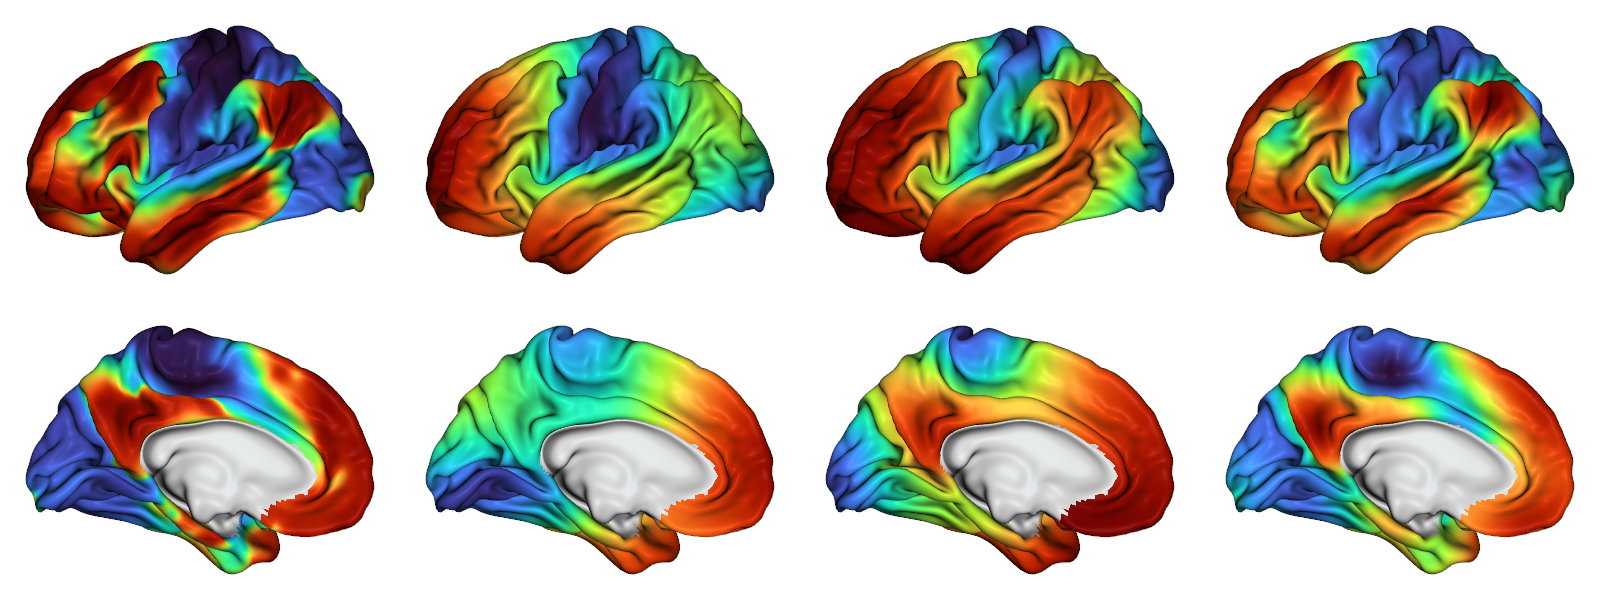

In [19]:
fig = plot_surf({'lh': geometry}, data={'lh': data_unmasked}, cmap='turbo', zoom=1.5, layout_indiv='col', views=['lateral', 'medial'])
fig.show(jupyter_backend='static')

### io

In [22]:
map_names = ['fcgradient1', 'myelinmap', 'thickness', 'odi', 'ndi']
maps = np.stack([fetch_map(name) for name in map_names], axis=1)
maps[~mask] = np.nan

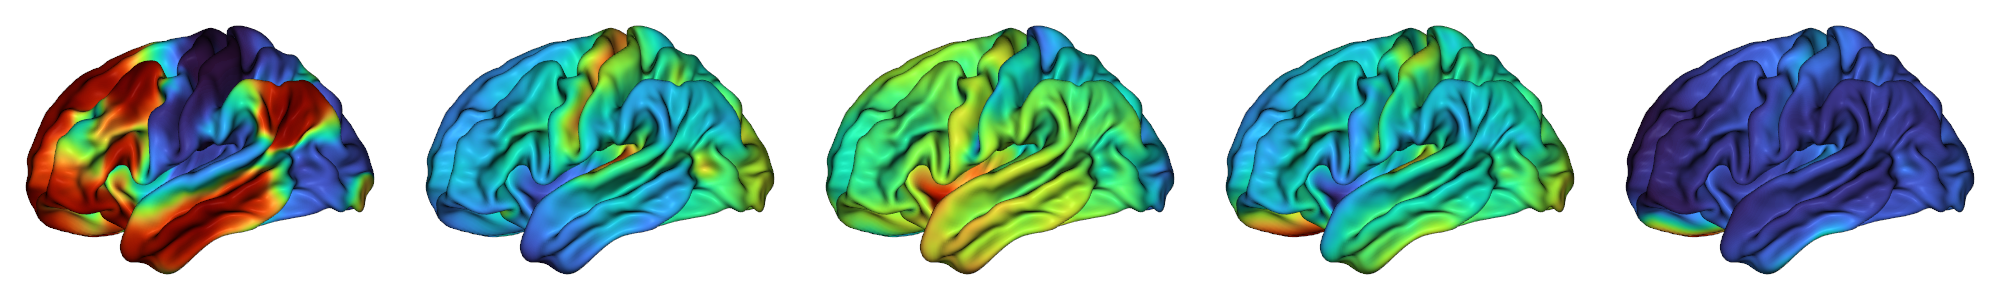

In [27]:
fig = plot_surf({'lh': geometry}, data={'lh': maps}, cmap='turbo', zoom=1.5)
fig.show(jupyter_backend='static')